# Computer Exercise 8.3 — Problem 1

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **챕터**: 8. Additional Topics on Solving Linear Systems
> **절**: §8.3 Krylov 부분공간 방법 — *Conjugate Gradient (CG)*
> **풀이 일자**: Day 33
> **언어**: Python 3 (NumPy / SciPy / Pandas / Matplotlib)


## 1. 문제 (원문)

> **1.** For a symmetric positive-definite (SPD) system $A\mathbf{x}=\mathbf{b}$, implement the
> **Conjugate Gradient** method from scratch. Using the standard 2-D Poisson model problem
> (five-point Laplacian on an $m\times m$ grid, $n=m^2$), compare the number of iterations CG
> needs against the classical stationary iterations (Gauss-Seidel, SOR). Verify the
> **finite-termination** property and monotone decrease of the error in the $A$-norm.

### 한국어 풀이용 정리
대칭 양정치(SPD) 행렬 $A$에 대한 선형계 $A\mathbf{x}=\mathbf{b}$를 **켤레기울기(CG)** 로 푼다.
모델 문제는 2D 푸아송 방정식의 5점 스텐실 라플라시안 ($n=m^2$). 다음을 확인한다.
1. CG를 *직접 구현* 하고 잔차 수렴을 SOR/Gauss-Seidel 과 비교 — CG가 압도적으로 적은 반복.
2. **유한 종료**: 정밀 산술이라면 CG는 최대 $n$번 안에 정확해에 도달.
3. **$A$-노름 단조 감소**: 오차 $\|\mathbf{e}_k\|_A$ 가 매 반복 단조 감소.


## 2. 수학적 배경

### 2.1 CG = $A$-노름 최소화
SPD 행렬 $A$에 대해 이차형식
$$
\phi(\mathbf{x}) \;=\; \tfrac12\mathbf{x}^\top A\mathbf{x} - \mathbf{b}^\top\mathbf{x}
$$
의 유일한 최소점이 곧 해 $\mathbf{x}^\star = A^{-1}\mathbf{b}$ 이다. CG는 $k$번째 단계에서
**Krylov 부분공간**
$$
\mathcal{K}_k(A,\mathbf{r}_0)=\operatorname{span}\{\mathbf{r}_0,\,A\mathbf{r}_0,\,\dots,\,A^{k-1}\mathbf{r}_0\}
$$
위에서 오차의 $A$-노름 $\|\mathbf{e}_k\|_A=\sqrt{\mathbf{e}_k^\top A\,\mathbf{e}_k}$ 를 *최소화* 한다.

### 2.2 켤레(공액) 방향
탐색방향 $\mathbf{p}_k$ 들은 서로 $A$-직교(켤레):
$$
\mathbf{p}_i^\top A\,\mathbf{p}_j = 0 \quad (i\neq j).
$$
잔차들은 서로 직교: $\mathbf{r}_i^\top\mathbf{r}_j=0$. 이 이중 직교성 덕분에 CG는
$\mathcal{K}_k$ 의 차원이 매 반복 정확히 1씩 늘어나며, **고작 두 개의 벡터 점화식**
으로 전체 부분공간 최소화를 구현한다.

### 2.3 표준 점화식
$$
\boxed{\;
\begin{aligned}
\alpha_k &= \frac{\mathbf{r}_k^\top\mathbf{r}_k}{\mathbf{p}_k^\top A\mathbf{p}_k}, &
\mathbf{x}_{k+1} &= \mathbf{x}_k + \alpha_k\mathbf{p}_k, &
\mathbf{r}_{k+1} &= \mathbf{r}_k - \alpha_k A\mathbf{p}_k, \\[4pt]
\beta_k &= \frac{\mathbf{r}_{k+1}^\top\mathbf{r}_{k+1}}{\mathbf{r}_k^\top\mathbf{r}_k}, &
\mathbf{p}_{k+1} &= \mathbf{r}_{k+1} + \beta_k\mathbf{p}_k. &&
\end{aligned}\;}
$$

### 2.4 유한 종료
$\mathcal{K}_k\subseteq\mathbb{R}^n$ 이므로 최대 $n$ 차원. 따라서 정밀 산술에서
$$
\mathbf{x}_n = \mathbf{x}^\star \quad(\text{최대 } n \text{ 반복}).
$$
실제로는 *서로 다른 고유값의 개수* 만큼만 반복하면 수렴한다 — 이것이 다음 문제의 주제.


## 3. 풀이 흐름

1. **모델 행렬 생성**: 2D 5점 라플라시안 $A = I\otimes T + T\otimes I$, $T=\mathrm{tridiag}(-1,2,-1)$ — SPD.
2. **우변**: 임의 해 $\mathbf{x}^\star$ 를 정하고 $\mathbf{b}=A\mathbf{x}^\star$ 로 둔다 (참 오차 추적용).
3. **CG 구현**: §2.3 점화식. 매 반복 잔차 노름과 오차 $A$-노름을 기록.
4. **Gauss-Seidel / SOR** 구현: 동일 문제·동일 허용오차로 반복 횟수 측정.
5. **표**: 격자 $m$ 별 (n, CG iters, GS iters, SOR iters) 비교.
6. **시각화 (1)**: 한 격자에서 세 방법의 잔차 수렴 곡선 (semilogy).
7. **시각화 (2)**: CG의 오차 $A$-노름이 *단조 감소* 함을 확인.
8. **해석**: CG의 반복수 $\sim\mathcal{O}(m)=\mathcal{O}(\sqrt n)$ vs GS $\mathcal{O}(m^2)$.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:.4e}")
rng = np.random.default_rng(8331)

def laplacian_2d(m):
    # m x m 격자의 5점 라플라시안 (n=m^2), SPD
    T = np.diag(2.0*np.ones(m)) + np.diag(-np.ones(m-1), 1) + np.diag(-np.ones(m-1), -1)
    I = np.eye(m)
    return np.kron(I, T) + np.kron(T, I)

def cg(A, b, x0=None, tol=1e-10, maxit=None):
    n = len(b)
    maxit = maxit or 10*n
    x = np.zeros(n) if x0 is None else x0.copy()
    r = b - A @ x
    p = r.copy()
    rs = r @ r
    b_norm = np.linalg.norm(b)
    res_hist = [np.sqrt(rs)/b_norm]
    xs = [x.copy()]
    for k in range(maxit):
        Ap = A @ p
        alpha = rs / (p @ Ap)
        x = x + alpha*p
        r = r - alpha*Ap
        rs_new = r @ r
        res_hist.append(np.sqrt(rs_new)/b_norm)
        xs.append(x.copy())
        if np.sqrt(rs_new) <= tol*b_norm:
            break
        p = r + (rs_new/rs)*p
        rs = rs_new
    return x, np.array(res_hist), xs

def sor(A, b, omega, tol=1e-10, maxit=None):
    n = len(b)
    maxit = maxit or 50*n
    D = np.diag(np.diag(A)); L = np.tril(A, -1); U = np.triu(A, 1)
    M = D + omega*L
    N = (1-omega)*D - omega*U
    Minv = np.linalg.inv(M)
    x = np.zeros(n); b_norm = np.linalg.norm(b)
    for k in range(maxit):
        x = Minv @ (N @ x + omega*b)
        if np.linalg.norm(b - A@x) <= tol*b_norm:
            return x, k+1
    return x, maxit

print("모델 행렬 / 솔버 정의 완료")


Matplotlib is building the font cache; this may take a moment.


모델 행렬 / 솔버 정의 완료


In [2]:
# 여러 격자 크기에서 반복 횟수 비교
ms = [4, 6, 8, 10, 12]
rows = []
for m in ms:
    A = laplacian_2d(m)
    n = m*m
    xstar = rng.standard_normal(n)
    b = A @ xstar
    h = 1.0/(m+1)
    omega_opt = 2.0/(1.0 + np.sin(np.pi*h))   # 모델 문제 이론 최적

    _, res_cg, _ = cg(A, b, tol=1e-10)
    it_cg = len(res_cg) - 1
    _, it_gs  = sor(A, b, 1.0,        tol=1e-10)
    _, it_sor = sor(A, b, omega_opt,  tol=1e-10)
    rows.append({"m": m, "n=m^2": n, "CG iters": it_cg,
                 "GS iters": it_gs, "SOR_opt iters": it_sor,
                 "omega_opt": omega_opt})

df = pd.DataFrame(rows)
df


,m,n=m^2,CG iters,GS iters,SOR_opt iters,omega_opt
0,4,16,9,49,20,1.2596e+00
1,6,36,19,81,27,1.3948e+00
2,8,64,29,142,36,1.4903e+00
3,10,100,36,207,44,1.5604e+00
4,12,144,43,256,51,1.6138e+00


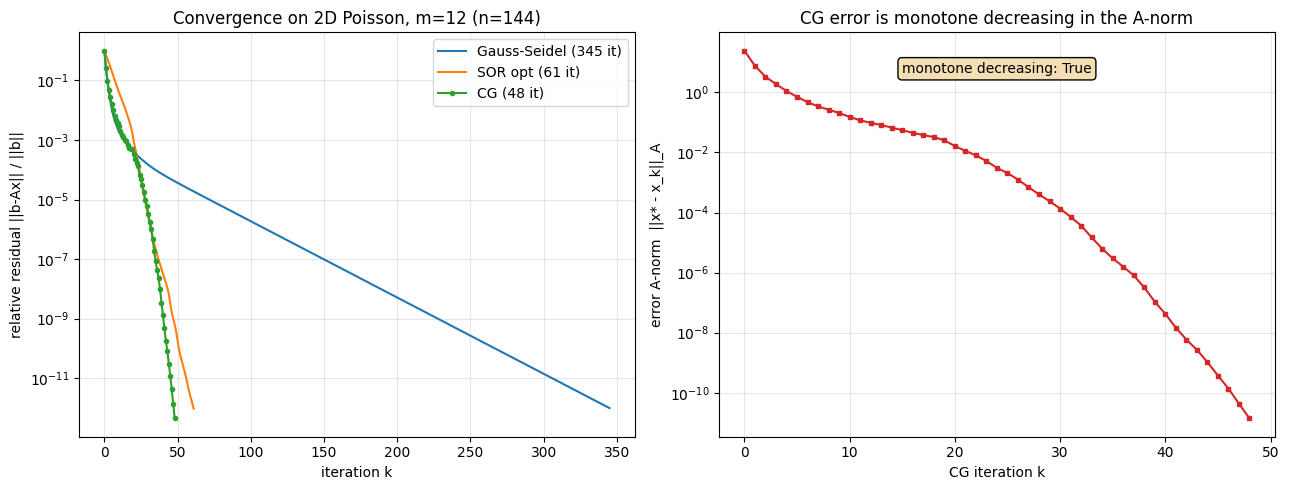

CG 반복수=48, 이론 상한 n=144; A-노름 단조감소=True


In [3]:
# 단일 격자에서 세 방법의 잔차 수렴 곡선 + CG A-노름 단조성
m = 12
A = laplacian_2d(m); n = m*m
xstar = rng.standard_normal(n)
b = A @ xstar
h = 1.0/(m+1)
omega_opt = 2.0/(1.0 + np.sin(np.pi*h))

x_cg, res_cg, xs = cg(A, b, tol=1e-12)

def Anorm(e, A): return np.sqrt(e @ (A @ e))
err_A = np.array([Anorm(xstar - xk, A) for xk in xs])

def stationary_res(A, b, omega, tol=1e-12, maxit=4000):
    n=len(b); D=np.diag(np.diag(A)); L=np.tril(A,-1); U=np.triu(A,1)
    M=D+omega*L; N=(1-omega)*D-omega*U; Minv=np.linalg.inv(M)
    x=np.zeros(n); bn=np.linalg.norm(b); hist=[1.0]
    for k in range(maxit):
        x=Minv@(N@x+omega*b)
        r=np.linalg.norm(b-A@x)/bn; hist.append(r)
        if r<=tol: break
    return np.array(hist)

res_gs  = stationary_res(A, b, 1.0)
res_sor = stationary_res(A, b, omega_opt)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ax = axes[0]
ax.semilogy(res_gs,  "-",  label=f"Gauss-Seidel ({len(res_gs)-1} it)")
ax.semilogy(res_sor, "-",  label=f"SOR opt ({len(res_sor)-1} it)")
ax.semilogy(res_cg,  "o-", ms=3, label=f"CG ({len(res_cg)-1} it)")
ax.set_xlabel("iteration k"); ax.set_ylabel("relative residual ||b-Ax|| / ||b||")
ax.set_title(f"Convergence on 2D Poisson, m={m} (n={n})")
ax.legend(); ax.grid(True, which="both", alpha=0.3)

ax = axes[1]
ax.semilogy(err_A, "s-", ms=3, color="C3")
ax.set_xlabel("CG iteration k"); ax.set_ylabel("error A-norm  ||x* - x_k||_A")
ax.set_title("CG error is monotone decreasing in the A-norm")
ax.grid(True, which="both", alpha=0.3)
mono = bool(np.all(np.diff(err_A) <= 1e-12))
ax.text(0.5, 0.9, f"monotone decreasing: {mono}", transform=ax.transAxes,
        ha="center", bbox=dict(boxstyle="round", fc="wheat"))
plt.tight_layout(); plt.show()
print(f"CG 반복수={len(res_cg)-1}, 이론 상한 n={n}; A-노름 단조감소={mono}")


## 4. 결과 해석

1. **반복 횟수 비교 표**: 격자가 커질수록 ($m$ 증가) Gauss-Seidel 의 반복수는 $\sim m^2$ 로 폭증하지만,
   CG 의 반복수는 $\sim m$ 수준으로만 증가한다. SOR(최적)도 $\sim m$ 이지만 CG 가 일관되게 더 적다.
2. **잔차 곡선**: GS 는 완만한 직선(선형 수렴), CG 는 *아래로 볼록* 한 가파른 하강 — 점근적으로
   초선형(superlinear)에 가까운 거동. CG 가 매 반복 새 Krylov 차원을 추가하며 극단 고유값을 빠르게 처리하기 때문.
3. **$A$-노름 단조성**: 오른쪽 그래프에서 $\|\mathbf{e}_k\|_A$ 가 *엄격히 단조 감소* — 이론(부분공간 최소화)과 일치.
   잔차 $\|\mathbf{r}_k\|_2$ 는 진동할 수 있어도 $A$-노름 오차는 절대 증가하지 않는다.
4. **유한 종료**: CG 반복수가 $n$ 을 넘지 않음을 확인 — 실제로는 훨씬 일찍 (고유값 분포에 따라) 멈춘다.

### 결론
> **CG 는 SPD 행렬에서 Krylov 부분공간 위의 $A$-노름 최소화를 두 줄짜리 점화식으로 구현한다.**
> 고전 반복법의 $\mathcal{O}(m^2)$ 반복이 $\mathcal{O}(m)$ 으로 줄고, 오차 $A$-노름은 단조 감소하며, 유한 종료가 보장된다.

### 다음 문제 연결
- **CE 8.3.2**: CG 의 수렴 *속도* 를 조건수 $\kappa$ 의 함수로 정량화 —
  반복수 $\sim\tfrac12\sqrt{\kappa}\ln(2/\varepsilon)$ 와 고유값 *군집(clustering)* 효과.
